#### Bibliotecas

In [2]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

#### Importando os dados

In [254]:
caminho_treino = "/home/dsenra/Documentos/GitHub/Housing_Prices_Kaggle/data/train.csv"
caminho_teste = "/home/dsenra/Documentos/GitHub/Housing_Prices_Kaggle/data/test.csv"

dados_treino = pd.read_csv(caminho_treino)
dados_teste = pd.read_csv(caminho_teste)

#### Início da análise exploratória e limpeza

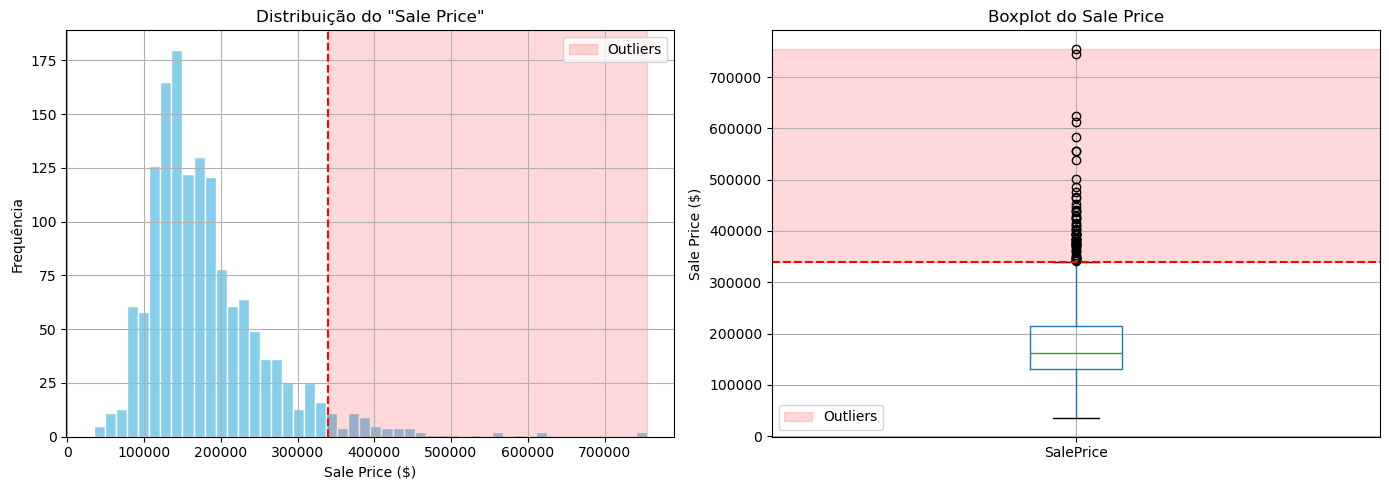

In [4]:
# Vamos iniciar avaliando a variável alvo SalePrice
# Eu gosto sempre de bater o olho no histrograma e boxplot

precos_casas = pd.DataFrame(dados_treino.SalePrice)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

#Histograma
precos_casas['SalePrice'].hist(bins=50, ax=axes[0], color='skyblue', edgecolor='white')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do "Sale Price"')
axes[0].axvspan(340000, precos_casas['SalePrice'].max(), color='red', alpha=0.15, label='Outliers')
axes[0].axvline(340000, color='red', linestyle='--', linewidth=1.5)
axes[0].legend()

# Boxplot
precos_casas.boxplot(column='SalePrice', ax=axes[1])
axes[1].set_ylabel('Sale Price ($)')
axes[1].set_title('Boxplot do Sale Price')
axes[1].axhspan(340000, precos_casas['SalePrice'].max(), color='red', alpha=0.15, label='Outliers')
axes[1].axhline(340000, color='red', linestyle='--', linewidth=1.5)
axes[1].legend()

plt.tight_layout()
plt.show()

Inicialmente vemos que a variável alvo (SalePrice) possui uma distribuição assimétrica com cauda para a direita. Em outras palavras, existem algumas casas com valores muito superiores a grande maioria, o que gera uma distorção nas estatísticas (média/desvio).
Provavelmente são imóveis de padrão alto luxo e/ou que estão em regiões mais caras. Levaremos isso em consideração mais a frente.

Como irei usar um modelo de árvore, podemos manter como está, mas será importante aplicar uma transformação log nessa variável alvo para que o modelo tenha uma boa performance.

In [5]:
estatisticas_precos = precos_casas.describe()

precos_estats = estatisticas_precos.loc[['50%', '75%', 'mean', 'std', 'min', 'max']].T
precos_estats['amplitude'] = precos_estats['max'] - precos_estats['min']
print(precos_estats.round(1))

                50%       75%      mean      std      min       max  amplitude
SalePrice  163000.0  214000.0  180921.2  79442.5  34900.0  755000.0   720100.0


In [6]:
maior_500k = (precos_casas['SalePrice']>500000).value_counts()
prop_maior_500k = (maior_500k/len(precos_casas))
print(prop_maior_500k.map("{:.2%}".format))

SalePrice
False    99.38%
True      0.62%
Name: count, dtype: str


Olhando para as estatísticas acima, a discrepância de preços fica mais evidente:
1) 75% das casas custam até USD 214k
2) Apenas 0.62% das casas custam mais do que USD 500k

Insights: Essa distribuição assimétrica gera problemas tanto para modelos lineares (devido a distorção da média/desvio) quanto para modelos de árvores que tendem a subestimar o preços de imóveis mais altos (devido ao baixo volume de dados).
De antemão, é muito provável que o grande desafio será atingir uma boa precisão para prever preços de casas de alto padrão/luxo.  

Abaixo vamos explorar as variáveis de entrada.

In [7]:
# Agora vamos iniciar uma avaliação das variáveis de entrada buscando as "Top 20" correlações
# Critério pessoal para selecionar top 20 = 25% dos dados totais
# Padronização de nome: como será aplicada a técnica de feature engineering ao longo do projeto, darei o nome
# de "features" para o conjunto de categorias/dados de cada casa.

matrix_corr = dados_treino.select_dtypes(include=[np.number]).corr()
top_corr_features = matrix_corr['SalePrice'].sort_values(ascending=False).head(21)

print("Top 20 variáveis numéricas que influenciam o preço:")
print(top_corr_features.round(2))

Top 20 variáveis numéricas que influenciam o preço:
SalePrice       1.00
OverallQual     0.79
GrLivArea       0.71
GarageCars      0.64
GarageArea      0.62
TotalBsmtSF     0.61
1stFlrSF        0.61
FullBath        0.56
TotRmsAbvGrd    0.53
YearBuilt       0.52
YearRemodAdd    0.51
GarageYrBlt     0.49
MasVnrArea      0.48
Fireplaces      0.47
BsmtFinSF1      0.39
LotFrontage     0.35
WoodDeckSF      0.32
2ndFlrSF        0.32
OpenPorchSF     0.32
HalfBath        0.28
LotArea         0.26
Name: SalePrice, dtype: float64


In [8]:
# Como ponto de corte para esta análise foram selecionadas todas com correlação > 0.3
top_corr_features = top_corr_features.drop(['HalfBath', 'LotArea'])
top_corr_features.round(2)

SalePrice       1.00
OverallQual     0.79
GrLivArea       0.71
GarageCars      0.64
GarageArea      0.62
TotalBsmtSF     0.61
1stFlrSF        0.61
FullBath        0.56
TotRmsAbvGrd    0.53
YearBuilt       0.52
YearRemodAdd    0.51
GarageYrBlt     0.49
MasVnrArea      0.48
Fireplaces      0.47
BsmtFinSF1      0.39
LotFrontage     0.35
WoodDeckSF      0.32
2ndFlrSF        0.32
OpenPorchSF     0.32
Name: SalePrice, dtype: float64

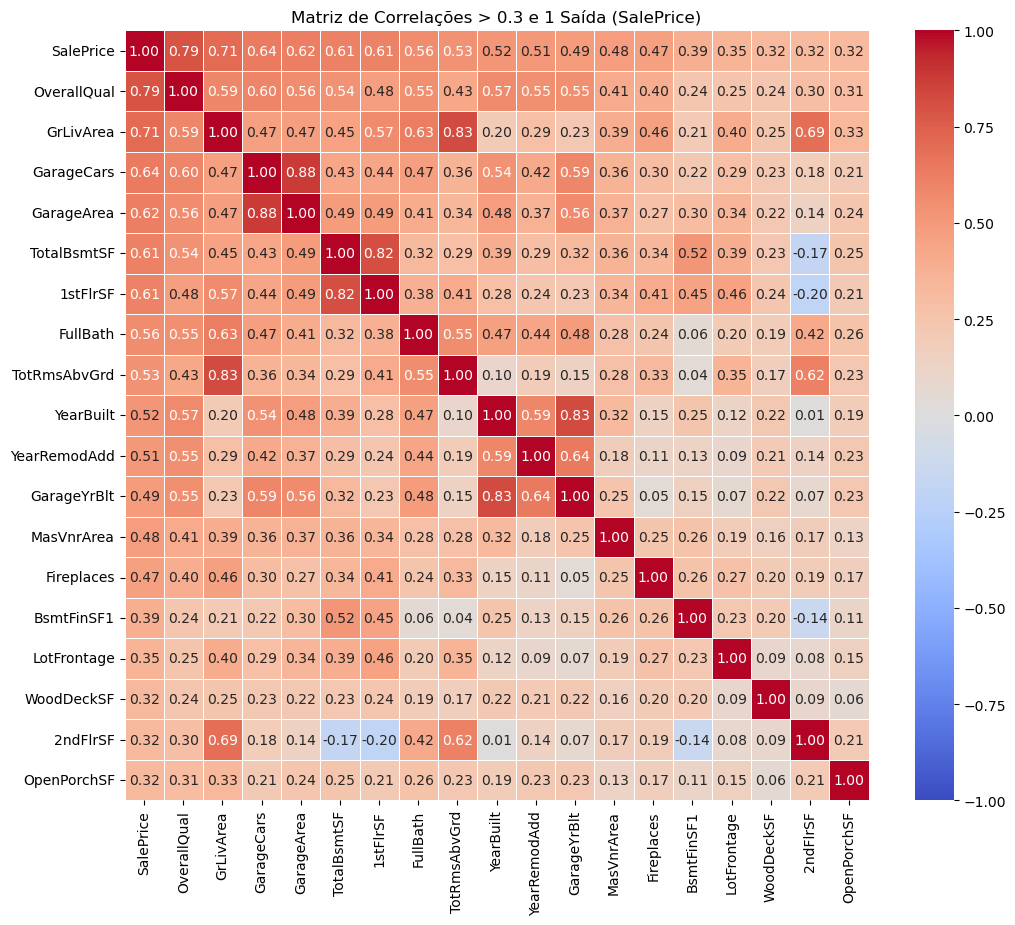

In [9]:
# Visualização gráficas das correlações > 0.3

plt.figure(figsize=(12, 10))
top_corr_features = matrix_corr.loc[top_corr_features.index, top_corr_features.index]
sns.heatmap(top_corr_features, 
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5, 
            vmin=-1, vmax=1)
plt.title('Matriz de Correlações > 0.3 e 1 Saída (SalePrice)')
plt.show()

In [10]:
# Avaliando se existem valores nulos nas features pré-selecionadas

features_nulos = ["SalePrice", "OverallQual",  "GrLivArea", "GarageCars","GarageArea", "TotalBsmtSF", "1stFlrSF", 
            "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MasVnrArea", "Fireplaces",
            "BsmtFinSF1", "LotFrontage", "WoodDeckSF", "2ndFlrSF", "OpenPorchSF"]

df_nulos = dados_treino[features_nulos.copy()]
print("Shape do df_nulos:", df_nulos.shape)
print("===========================================\n\n Info do df_nulos:", )
print(df_nulos.info())

Shape do df_nulos: (1460, 19)

 Info do df_nulos:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SalePrice     1460 non-null   int64  
 1   OverallQual   1460 non-null   int64  
 2   GrLivArea     1460 non-null   int64  
 3   GarageCars    1460 non-null   int64  
 4   GarageArea    1460 non-null   int64  
 5   TotalBsmtSF   1460 non-null   int64  
 6   1stFlrSF      1460 non-null   int64  
 7   FullBath      1460 non-null   int64  
 8   TotRmsAbvGrd  1460 non-null   int64  
 9   YearBuilt     1460 non-null   int64  
 10  YearRemodAdd  1460 non-null   int64  
 11  GarageYrBlt   1379 non-null   float64
 12  MasVnrArea    1452 non-null   float64
 13  Fireplaces    1460 non-null   int64  
 14  BsmtFinSF1    1460 non-null   int64  
 15  LotFrontage   1201 non-null   float64
 16  WoodDeckSF    1460 non-null   int64  
 17  2ndFlrSF      1460 non-null   in

Das 18 features listadas acima apenas 3 possuem valores nulos:
GarageYrBlt (~5.5%), MasVnrArea (~0.5%) e LotFrontage (~18%).

Por ora vamos apenas criar um função que preenche esses valores com zeros e avaliar a performance dos modelos ao longo do projeto. A função irá cobrir todas features para ser aplicada nos dados de teste (precaução caso existam dados nulos).

In [255]:
def preenche_nulos_numericos(df):
    features_nulos = ["OverallQual",  "GrLivArea", "GarageCars","GarageArea", "TotalBsmtSF", "1stFlrSF", 
            "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MasVnrArea", "Fireplaces",
            "BsmtFinSF1", "LotFrontage", "WoodDeckSF", "2ndFlrSF", "OpenPorchSF"]
    
    df[features_nulos] = df[features_nulos].fillna(0)
    return df

In [256]:
# Preenchendo nulos antes de criar novas features

df_treino_1 = dados_treino.copy()
df_treino_1 = preenche_nulos_numericos(df_treino_1)

#### Feature Engineering: Parte 1

Agora vamos dar início a criação de novas features para extrair mais informações dos dados.

In [257]:
#Feature Engineering: Parte 1 - Correlações acima de 0.3

def feature_engineering_1(df):
    # YearBuilt, YearRemodAdd e GarageAge: Ao invés de usar o ano vamos calcular a idade do imóvel
    # Padronização de nomes: mantendo as variáveis dos datasets em inglês
    
    ano_atual = datetime.datetime.now().year
    df['HouseAge'] = ano_atual - df['YearBuilt']
    df['RemodAge'] = ano_atual - df['YearRemodAdd']
    df['GarageAge'] = ano_atual - df['GarageYrBlt']

    # Para a Qualidade, ao invés de usar apenas o OverallQual, criamos uma combinação com OverallCond
    df["OverallScore"] = df["OverallQual"]+df["OverallCond"]

    #Aplica-se também a mesma lógica para área total e número de banheiros
    df['TotalArea'] = df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBaths'] = df['FullBath'] + (0.5 * df['HalfBath'])

    # Para OpenPorchSF (varandas) vamos considerar a soma de todos estilos
    df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
    return df

In [258]:
df_treino_1 = feature_engineering_1(df_treino_1)

In [15]:
# Iniciando a lista de features e df_treino para o modelo inicial
features_lista = ["OverallScore",  "GrLivArea", "GarageCars","GarageArea", 
                  "TotalBsmtSF", "TotalBaths", "TotRmsAbvGrd", 
                  "GarageAge", "MasVnrArea", "Fireplaces", 
                  "BsmtFinSF1","LotFrontage", "HouseAge", "RemodAge",
                  "TotalArea", "TotalPorchSF"]

df_treino_round_1 = df_treino_1[features_lista]

Agora vamos dar uma olhada na variabilidade das features selecionadas.
Para isso vou avaliar as estatísticas básicas de cada feature.

In [16]:
estatisticas_df = df_treino_round_1.describe()

df_estats = estatisticas_df.loc[['50%', 'mean', 'std', 'min', 'max']].T
df_estats['amplitude'] = df_estats['max'] - df_estats['min']
print(df_estats)

                 50%         mean         std    min     max  amplitude
OverallScore    12.0    11.674658    1.693527    2.0    19.0       17.0
GrLivArea     1464.0  1515.463699  525.480383  334.0  5642.0     5308.0
GarageCars       2.0     1.767123    0.747315    0.0     4.0        4.0
GarageArea     480.0   472.980137  213.804841    0.0  1418.0     1418.0
TotalBsmtSF    991.5  1057.429452  438.705324    0.0  6110.0     6110.0
TotalBaths       2.0     1.756507    0.636015    0.0     3.5        3.5
TotRmsAbvGrd     6.0     6.517808    1.625393    2.0    14.0       12.0
GarageAge       49.0   157.260274  453.697295   16.0  2026.0     2010.0
MasVnrArea       0.0   103.117123  180.731373    0.0  1600.0     1600.0
Fireplaces       1.0     0.613014    0.644666    0.0     3.0        3.0
BsmtFinSF1     383.5   443.639726  456.098091    0.0  5644.0     5644.0
LotFrontage     63.0    57.623288   34.664304    0.0   313.0      313.0
HouseAge        53.0    54.732192   30.202904   16.0   154.0    

Quatro coisas chamam atenção na tabela acima:
1) Várias features possuem um desvio padrão bem alto.
2) A feature "MasVnrArea" possui mediana 0 e média 103.1. Isso significa que ela possui uma alta quantidade de zeros (>50%).
3) Algumas variáveis possuem escala bastante discrepante se comparadas as demais, são elas: GrLivArea, GarageArea, MasVnrArea, TotalBsmtSF, BsmtFinSF1, TotalArea e TotalPorchSF.
4) A nova variável criada "TotalArea" parece estar redundante, pois possui valores muito similares a "GrLivArea", o que faz sentido pela descrição do dataset. Portanto vamos removê-la da análise.

Vamos tratar esses pontos, começando com a alta quantidade de zeros. Para isso vamos estender essa avaliação para as demais features numéricas:

In [17]:
# Avaliando a porcentagem de zeros em todas as colunas numéricas
zeros_por_coluna = (df_treino_round_1 == 0).mean()
analise_zeros = zeros_por_coluna[zeros_por_coluna > 0].sort_values(ascending=False)

print("% Zeros por Feature:")
print(analise_zeros.map("{:.2%}".format))

% Zeros por Feature:
MasVnrArea      59.52%
Fireplaces      47.26%
BsmtFinSF1      31.99%
TotalPorchSF    31.37%
LotFrontage     17.74%
GarageCars       5.55%
GarageArea       5.55%
TotalBsmtSF      2.53%
TotalBaths       0.21%
dtype: str


4 das features possuem uma quantidade de zeros muito alta (>30%) e 1 com 17%.
Neste caso vamos criar uma nova feature booleana que indicará a presença ou não das features com proporção > 30%.
Isso facilita a lógica das árvores, pois irá avaliar o quantitativo somente daquelas que cairem nas árvores com valor = 1 (positivo).

Vamos também remover a variável criada "TotalArea".

In [ ]:
#Feature Engineering: Parte 1 - atualizada para tratar alta proporção de zeros

def feature_engineering_1(df):
    # YearBuilt, YearRemodAdd e GarageAge: Ao invés de usar o ano vamos calcular a idade do imóvel
    # Padronização de nomes: mantendo as variáveis dos datasets em inglês
    
    ano_atual = datetime.datetime.now().year
    df['HouseAge'] = ano_atual - df['YearBuilt']
    df['RemodAge'] = ano_atual - df['YearRemodAdd']
    df['GarageAge'] = ano_atual - df['GarageYrBlt']

    # Para a Qualidade, ao invés de usar apenas o OverallQual, criamos uma combinação com OverallCond
    df["OverallScore"] = df["OverallQual"]+df["OverallCond"]

    #Aplica-se também a mesma lógica para o número total de banheiros
    df['TotalBaths'] = df['FullBath'] + (0.5 * df['HalfBath'])

    # Para OpenPorchSF (varandas) vamos considerar a soma de todos estilos
    df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']

    # nova variável booleana para separar casas com valores zero
    df['HasMasVnr'] = (df['MasVnrArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['HasBsmtFin'] = (df['BsmtFinSF1'] > 0).astype(int)
    df['HasPorch'] = (df['TotalPorchSF'] > 0).astype(int)
    return df

Agora dando sequência as pontos levantados anteriormente, vamos avaliar a variabilidade das features com valores mais altos:

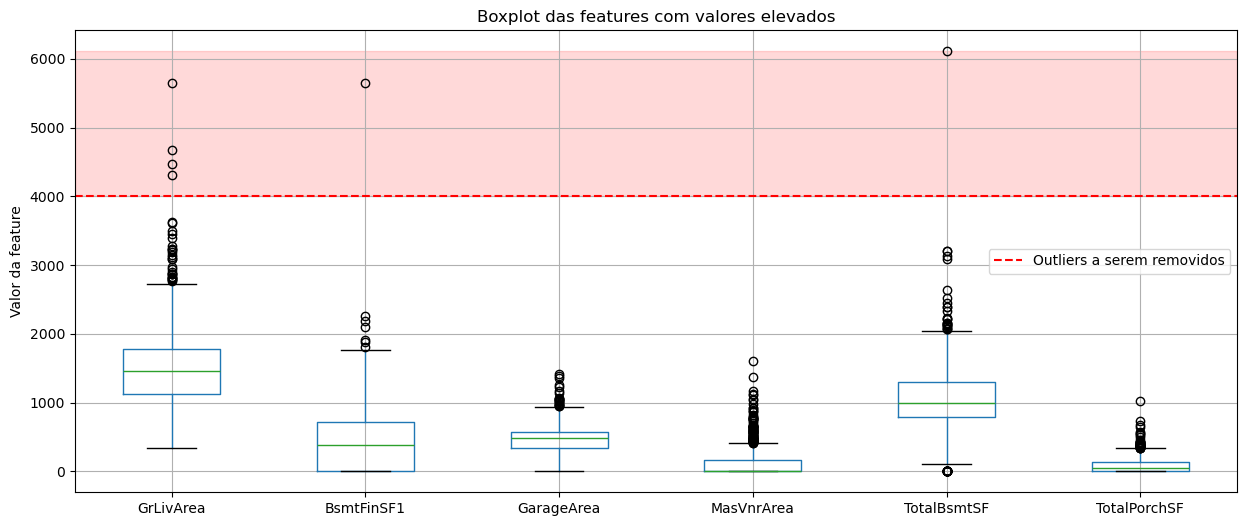

In [19]:
features_escala_alta = ["GrLivArea", "BsmtFinSF1", "GarageArea", "MasVnrArea", "TotalBsmtSF","TotalPorchSF"]
df_analise_escala = df_treino_1[features_escala_alta]

plt.figure(figsize=(15, 6))
plt.ylabel('Valor da feature')
plt.title('Boxplot das features com valores elevados')
plt.axhline(4000, color='red', linestyle='--', linewidth=1.5, label='Outliers a serem removidos')
plt.axhspan(4000, df_analise_escala['TotalBsmtSF'].max(), color='red', alpha=0.15)
df_analise_escala.boxplot()
plt.legend()
plt.show()

No geral existem muitos outliers, mas provavelmente o XGBoost não será tão afetado como aconteceria por um modelo de regressão linear.
Porém os valores discrepantes serão eliminados (>4000), uma vez que trata-se de uma quantidade muito baixa para um data set de 1460.

In [20]:
# Verificando os ID's das casas na região que delimitei como área de corte dos outliers

outliers_GrLivArea = df_treino_1[df_treino_1['GrLivArea'] > 4000]
outliers_BsmtFinSF1 = df_treino_1[df_treino_1['BsmtFinSF1'] > 4000]
outliers_TotalBsmtSF = df_treino_1[df_treino_1['TotalBsmtSF'] > 4000]

print(f"IDs com GrLivArea > 4000: {outliers_GrLivArea.index.tolist()}")
print(f"IDs com BsmtFinSF1 > 4000: {outliers_BsmtFinSF1.index.tolist()}")
print(f"IDs com TotalBsmtSF > 4000: {outliers_TotalBsmtSF.index.tolist()}")

IDs com GrLivArea > 4000: [523, 691, 1182, 1298]
IDs com BsmtFinSF1 > 4000: [1298]
IDs com TotalBsmtSF > 4000: [1298]


Neste caso sabemos que os 6 pontos do gráfico anterior referem-se a 4 casas.  
Abaixo essas casas serão removidas do conjunto de dados de treino:

In [260]:
# Remoção de outliers
remover_outliers = (
    (dados_treino['GrLivArea'] > 4000) |
    (dados_treino['BsmtFinSF1'] > 4000)|
    (dados_treino['TotalBsmtSF'] > 4000)
)

df_treino_1_limpo = df_treino_1[~remover_outliers].copy()

print(f"Linhas originais: {len(dados_treino)}")
print(f"Linhas após remoção: {len(df_treino_1_limpo)}")
print(f"Total de outliers removidos: {len(dados_treino) - len(df_treino_1_limpo)}")

df_treino_1_sem_outliers = df_treino_1_limpo.copy()

Linhas originais: 1460
Linhas após remoção: 1456
Total de outliers removidos: 4


#### Treino e Validação - 1º e 2º Rodadas

Vamos então partir para a primeira rodada de treino e validação. A partir do que foi visto na análise exploratória acima, vamos partir para modelos de árvores, começando com os dois principais xgboost e random forest.

In [46]:
# Criação de 2 modelos: XGBoost e Random Forest
# Treino e Validação

features_final = ["OverallScore",  "GrLivArea", "GarageCars","GarageArea", 
                  "TotalBsmtSF", "TotalBaths", "TotRmsAbvGrd", 
                  "GarageAge", "MasVnrArea", "Fireplaces", 
                  "BsmtFinSF1","LotFrontage", "HouseAge", "RemodAge",
                  "TotalPorchSF", "HasMasVnr", "HasFireplace", 
                  "HasBsmtFin", "HasPorch"]

df_treino_1_sem_outliers = feature_engineering_1(df_treino_1_sem_outliers)
df_treino_round_1 = df_treino_1_sem_outliers[features_final]

# 1º Rodada
y = df_treino_1_sem_outliers.SalePrice

X = df_treino_round_1
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

#XGBoost
# Chutando um n arvores mais alto e learning rate e max_depth mais baixo para evitar overfitting
xgb_model_1 = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=0, n_jobs = -1)
xgb_model_1.fit(X_train, np.log(y_train), eval_set=[(X_valid, np.log(y_valid))], verbose=100)

xgb_preds_1 = np.exp(xgb_model_1.predict(X_valid))

scores = -1 * cross_val_score(xgb_model_1, X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"MAE Médio (Cross-Validation): {scores.mean()}")
print("XGBoost Mean Absolute Error:", mean_absolute_error(y_valid, xgb_preds_1))  

#Random Forest
rf_model = RandomForestRegressor(n_estimators=500, random_state=0)
rf_model.fit(X_train, np.log(y_train))
rf_preds = np.exp(rf_model.predict(X_valid))
print("Random Forest Mean Absolute Error:", mean_absolute_error(y_valid, rf_preds))  


[0]	validation_0-rmse:0.36309
[100]	validation_0-rmse:0.12102
[200]	validation_0-rmse:0.12301
[300]	validation_0-rmse:0.12431
[400]	validation_0-rmse:0.12583
[499]	validation_0-rmse:0.12616
MAE Médio (Cross-Validation): 16643.1552734375
XGBoost Mean Absolute Error: 16066.9345703125
Random Forest Mean Absolute Error: 16636.61214380441


Os modelos apresentaram uma performance muito similar, sendo que o Random Forest ficou ligeiramente pior comparado ao xgbost.
Muito provavelmente ambos podem melhorar através de otimizações dos hiperparâmetros (inclusive o xgboost obteve melhores resultados em torno de 100 estimadores), mas antes vamos avaliar como ficaram os resíduos de cada modelo.  
Foram inseridas duas linhas de referências (+/- USD 50k), o que seria considerado uma margem bastante razoável para um modelo extremamente generalista.

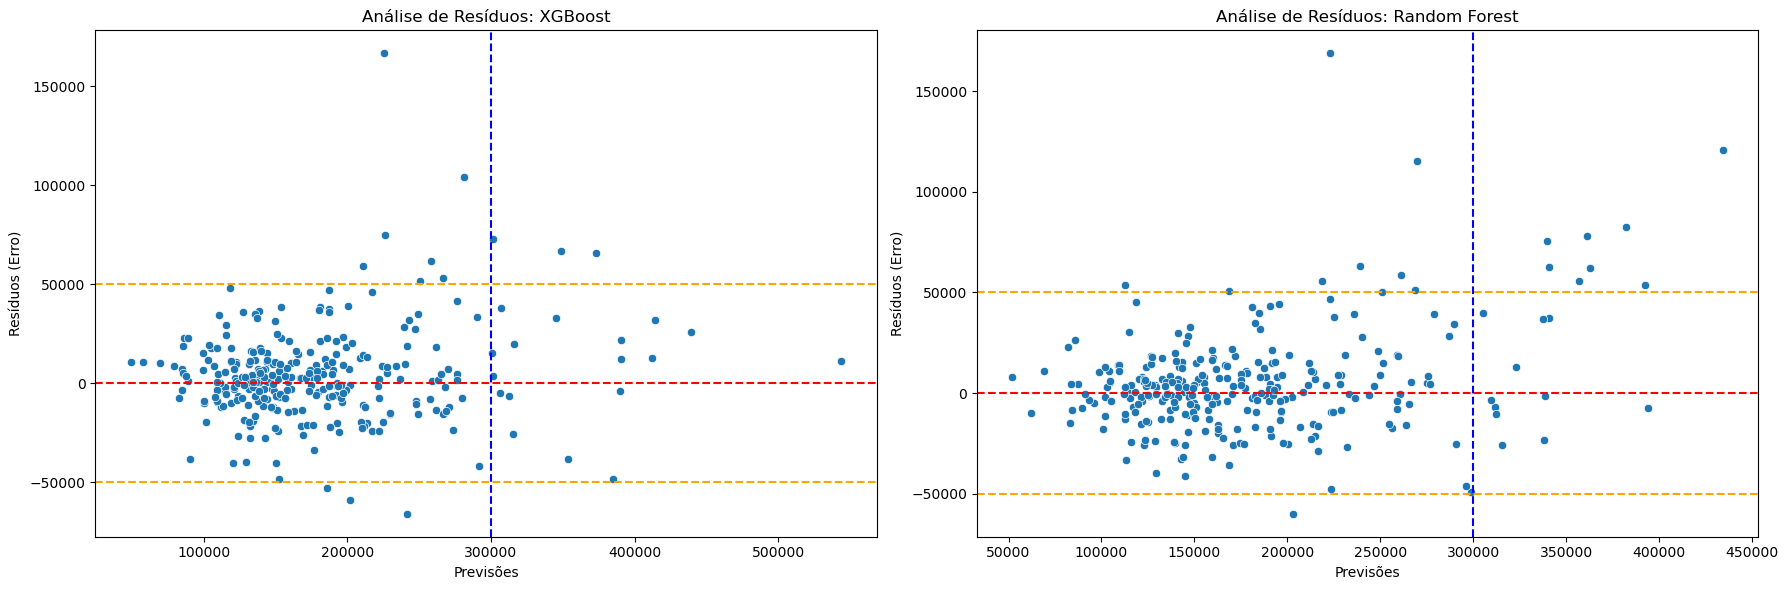

In [47]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# XGBoost
residuals_xgb_1 = y_valid - xgb_preds_1

sns.scatterplot(x=xgb_preds_1, y=residuals_xgb_1, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].axhline(y=50000, color='orange', linestyle='--')
axes[0].axhline(y=-50000, color='orange', linestyle='--')
axes[0].axvline(x=300000, color='blue', linestyle='--')
axes[0].set_xlabel('Previsões')
axes[0].set_ylabel('Resíduos (Erro)')
axes[0].set_title('Análise de Resíduos: XGBoost')

# Random Forest
residuals_rf_1 = y_valid - rf_preds

sns.scatterplot(x=rf_preds, y=residuals_rf_1, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].axhline(y=50000, color='orange', linestyle='--')
axes[1].axhline(y=-50000, color='orange', linestyle='--')
axes[1].axvline(x=300000, color='blue', linestyle='--')
axes[1].set_xlabel('Previsões')
axes[1].set_ylabel('Resíduos (Erro)')
axes[1].set_title('Análise de Resíduos: Random Forest')

plt.tight_layout()
plt.show()

Os gráficos de resíduos trazem algumas informações:
1) Visualmente não existe um padrão no comportamento dos resíduos o que indica homocedasticidade para ambos modelos
2) O XGBoost tratou melhor as casas com valores acima de USD 300k quando comparado ao Random Forest.
3) O XGBoost performou um pouco pior nas casas com valores intermediários, sendo que ambos obtiveram alguns erros bem elevados entre aproximadamente USD 200k e USD 300k.
3) Para a primeira rodada, considerando uma meta de +/- USD 50k, o modelo apresentou uma performance razoável. 

Agora vamos avaliar tanto os erros quanto as variáveis que tiveram outliers removidos. A ideia é ver se existe algum padrão que possa ajudar a diminuir os erros. Vamos focar no XGBoost por ter apresentado um resultado superior.

In [92]:
features = ['Preco_Real', 'Previsao', 'Erro_Absoluto', 'Bairro']

analise_erro = X_valid.copy()
analise_erro['Preco_Real'] = y_valid
analise_erro['Previsao'] = xgb_preds_1
analise_erro['Erro_Absoluto'] = abs(y_valid - xgb_preds_1)
analise_erro['Bairro'] = dados_treino.Neighborhood
analise_erro = analise_erro[features]

print("\nMaiores 10 erros:")
maiores_erros = analise_erro.sort_values(by='Erro_Absoluto', ascending=False)
print(maiores_erros.head(15))
print("=======================================================")
print("\nMenores 10 erros:")
menores_erros = analise_erro.sort_values(by='Erro_Absoluto')
print(menores_erros.head(15))
print("=======================================================")

contagem_bairros = analise_erro['Bairro'].value_counts()
print("\nContagem por bairros:")
print(contagem_bairros)



Maiores 10 erros:
      Preco_Real       Previsao  Erro_Absoluto   Bairro
688       392000  225286.156250  166713.843750  StoneBr
53        385000  280951.843750  104048.156250  Veenker
322       301000  225997.359375   75002.640625  SawyerW
481       374000  301173.656250   72826.343750  NridgHt
278       415298  348452.468750   66845.531250  NridgHt
1415      175900  241729.031250   65829.031250  Blmngtn
58        438780  373158.500000   65621.500000  StoneBr
45        319900  257895.078125   62004.921875  NridgHt
764       270000  210873.984375   59126.015625  Veenker
588       143000  201881.078125   58881.078125  ClearCr
159       320000  266749.000000   53251.000000  Gilbert
491       133000  185781.953125   52781.953125    NAmes
706       302000  250359.343750   51640.656250  ClearCr
198       104000  152338.421875   48338.421875  OldTown
763       337000  385108.875000   48108.875000  NoRidge

Menores 10 erros:
      Preco_Real       Previsao  Erro_Absoluto   Bairro
1401      

Essa análise acima trás uma informação muito interessante: ao todos 13 previsões tiveram erros acima de USD 50k, sendo que eles estão majoritariamente presente nos bairros com pouca quantidade de dados. Veja abaixo:  

1) Ao todo existem 24 bairros registrados
2) Das 13 previsões com maiores erros, 7 estão relacionadas com apenas 4 bairros (StoneBr, Veenker, Blmngtn e ClearCr). Ou seja, 17% dos bairros se relacionam com 54% do total de previsões com erros elevados.
3) Todos os bairros listados no item 2 possuem um baixo número de dados (apenas 5 registros por bairro)
4) As casas com maiores erros foram as de ID 688 e 53.  

Contudo vamos criar uma nova variável "Região" que irá agrupar os bairros de acordo com a geografia da cidade de Ames, Iowa:

In [262]:
def mapear_regioes_ames(df):
    # Dicionário baseado na geografia real de Ames, Iowa
    #A criação deste dicionário foi feita com auxílio de IA e Google Maps
    mapa_regioes = {
        # Norte
        'Blmngtn': 'North',
        'Gilbert': 'North',
        'NoRidge': 'North', 
        'NridgHt': 'North',
        'StoneBr': 'North', 
        'Veenker': 'North', 
        'NPkVill': 'North',
        
        # Noroeste/Oeste
        'NWAmes': 'NorthWest',
        'Names': 'NorthWest',
        'CollgCr': 'West',
        'Sawyer': 'West', 
        'SawyerW': 'West', 
        'ClearCr': 'West',
        
        # Central
        'OldTown': 'Center',
        'BrkSide': 'Center', 
        'IDOTRR': 'Center',
        'Somerst': 'Center',
        
        # Sul
        'SWISU': 'South',
        'Edwards': 'South', 
        'Timber': 'South', 
        'MeadowV': 'South',
        
        # LEste
        'Mitchel': 'East', 
        'BrDale': 'East', 
        'Blueste': 'East' 
    }
    df['Region'] = df['Neighborhood'].map(mapa_regioes)
    
    return df

In [179]:
# 2º Rodada aplicando o filtro de regiões: XGBoost
# Treino e Validação

features_final = ["OverallScore", "GrLivArea", "GarageCars","GarageArea", 
                  "TotalBsmtSF", "TotalBaths", "TotRmsAbvGrd", 
                  "GarageAge", "MasVnrArea", "Fireplaces", 
                  "BsmtFinSF1","LotFrontage", "HouseAge", "RemodAge",
                  "TotalPorchSF", "HasMasVnr", "HasFireplace", 
                  "HasBsmtFin", "HasPorch", "Region"]

df_treino_1_sem_outliers = feature_engineering_1(df_treino_1_sem_outliers)
df_treino_round_1 = mapear_regioes_ames(df_treino_1_sem_outliers)

y = df_treino_1_sem_outliers.SalePrice
X = pd.get_dummies(df_treino_round_1[features_final], drop_first=True)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

#XGBoost
xgb_model_2 = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=0, n_jobs = -1)

xgb_model_2.fit(X_train, np.log(y_train), eval_set=[(X_valid, np.log(y_valid))], verbose=100)
xgb_preds_2 = np.exp(xgb_model_2.predict(X_valid))

scores = -1 * cross_val_score(xgb_model_2, X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"MAE Médio (Cross-Validation): {scores.mean()}")
print("XGBoost Mean Absolute Error:", mean_absolute_error(y_valid, xgb_preds_2))  


[0]	validation_0-rmse:0.36309
[100]	validation_0-rmse:0.11942
[200]	validation_0-rmse:0.12027
[300]	validation_0-rmse:0.11984
[400]	validation_0-rmse:0.12009
[499]	validation_0-rmse:0.12047
MAE Médio (Cross-Validation): 16559.970703125
XGBoost Mean Absolute Error: 15608.3232421875


In [180]:
print("Contagem de casas por regiôes:")
df_treino_round_1['Region'].value_counts()

Contagem de casas por regiôes:


Region
West         311
Center       294
North        257
South        178
NorthWest     73
East          67
Name: count, dtype: int64

Observações:  
1) Apesar da classificação por regiões ter reduzido drasticamente os grupos minoritários, ainda existe uma diferença relevante entre os 3 primeiros (>250 casas) com os 2 últimos (~70 casas).  
2) O impacto no MAE foi irrelevante (<1%), apesar de contribuir para um valor ligeiramente abaixo de 16k.
  
Vamos comparar os resíduos antes x após o filtro de regiôes:

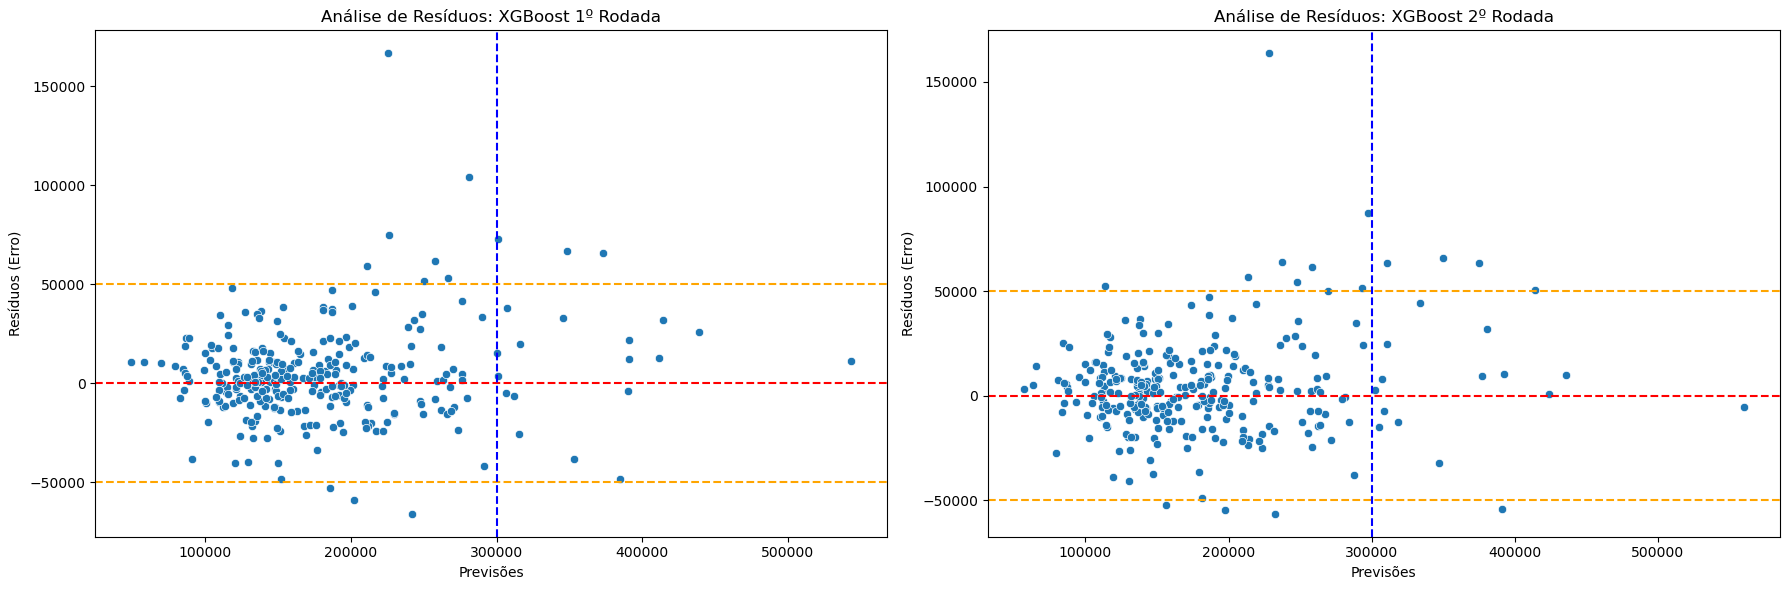

In [181]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# XGBoost 1º Rodada
sns.scatterplot(x=xgb_preds_1, y=residuals_xgb_1, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].axhline(y=50000, color='orange', linestyle='--')
axes[0].axhline(y=-50000, color='orange', linestyle='--')
axes[0].axvline(x=300000, color='blue', linestyle='--')
axes[0].set_xlabel('Previsões')
axes[0].set_ylabel('Resíduos (Erro)')
axes[0].set_title('Análise de Resíduos: XGBoost 1º Rodada')

# XGBoost 2º Rodada
residuals_xgb_2 = y_valid - xgb_preds_2
sns.scatterplot(x=xgb_preds_2, y=residuals_xgb_2, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].axhline(y=50000, color='orange', linestyle='--')
axes[1].axhline(y=-50000, color='orange', linestyle='--')
axes[1].axvline(x=300000, color='blue', linestyle='--')
axes[1].set_xlabel('Previsões')
axes[1].set_ylabel('Resíduos (Erro)')
axes[1].set_title('Análise de Resíduos: XGBoost 2º Rodada')

plt.tight_layout()
plt.show()

Por fim, vamos avaliar a ocorrência de bairros por maiores erros:

In [182]:
features = ['Preco_Real', 'Previsao', 'Erro_Absoluto', 'Bairro']

analise_erro = X_valid.copy()
analise_erro['Preco_Real'] = y_valid
analise_erro['Previsao'] = xgb_preds_2
analise_erro['Erro_Absoluto'] = abs(y_valid - xgb_preds_2)
analise_erro['Bairro'] = dados_treino.Neighborhood
analise_erro = analise_erro[features]

print("\nMaiores 15 erros:")
maiores_erros = analise_erro.sort_values(by='Erro_Absoluto', ascending=False)
print(maiores_erros.head(15))


Maiores 15 erros:
      Preco_Real       Previsao  Erro_Absoluto   Bairro
688       392000  228373.656250  163626.343750  StoneBr
53        385000  297432.750000   87567.250000  Veenker
278       415298  349598.187500   65699.812500  NridgHt
322       301000  237258.937500   63741.062500  SawyerW
481       374000  310556.750000   63443.250000  NridgHt
58        438780  375402.250000   63377.750000  StoneBr
159       320000  258682.312500   61317.687500  Gilbert
764       270000  213425.046875   56574.953125  Veenker
1415      175900  232242.515625   56342.515625  Blmngtn
588       143000  197689.187500   54689.187500  ClearCr
706       302000  247630.953125   54369.046875  ClearCr
763       337000  391047.375000   54047.375000  NoRidge
142       166000  113704.843750   52295.156250    NAmes
198       104000  156042.375000   52042.375000  OldTown
642       345000  293595.187500   51404.812500    NAmes


A partir da tabela acima podemos ver:  
- A classificação por região pouco ajudou na previsão da casa de ID 688, com uma queda de apenas 1.8% (de USD 166713k para USD 163626k). Existe algum padrão que o modelo aprendeu (ou faltou aprender) que está induzindo ao erro para este imóvel em específico.
- Já para o imóvel de ID 53 houve uma queda de 15.8% (de USD 104048k para USD 87567k). Entender a diferença entre estes dois imóveis pode ser uma dica do fator relevante.
- Uma casa que chama atenção é a de ID 58, pois também está em StoneBr e possui um erro muito inferior a de ID 688.
- No geral todas as demais casas que antes estava acima da linha de 50k também tiveram uma leve redução no erro.
- O erro continua concentrado nos mesmos bairros que foram listados anteriormente.  

Portanto, considerando que o ganho de performace no MAE foi irrelevante, mas houve uma leve redução no erro da maioria das previsões, a decisão é de manter o filtro de região por ora, porém vamos continuar buscando outra variável que explique melhor os valores mais elevados de algumas casas (visto que no geral o modelo tem errado para baixo).

Vamos investigar as duas casas com maiores erros. Para isso vamos listar a casa de ID 58 e também as casas com menores erros do X_valid e então comparar com a tabela anterior (maiores erros):

In [186]:
features = ['Preco_Real', 'Previsao', 'Erro_Absoluto', 'Bairro']

analise_erro = X_valid.copy()
analise_erro['Preco_Real'] = y_valid
analise_erro['Previsao'] = xgb_preds_2
analise_erro['Erro_Absoluto'] = abs(y_valid - xgb_preds_2)
analise_erro['Bairro'] = dados_treino.Neighborhood
analise_erro = analise_erro[features]

print("Menores 5 erros:")
maiores_erros = analise_erro.sort_values(by='Erro_Absoluto', ascending=False)
print(maiores_erros.tail(10))

Menores 5 erros:
      Preco_Real       Previsao  Erro_Absoluto   Bairro
622       135000  134516.421875     483.578125   Sawyer
1289      281000  281462.437500     462.437500  NridgHt
1097      170000  169549.015625     450.984375  StoneBr
483       164000  164399.625000     399.625000  Mitchel
241       110500  110857.210938     357.210938  OldTown
353       105900  106214.757812     314.757812  OldTown
922       169990  169773.921875     216.078125  Gilbert
957       132000  132153.000000     153.000000   Sawyer
1         181500  181644.546875     144.546875  Veenker
1088      137500  137409.250000      90.750000  Edwards


Para fazer uma investigação sem incluir novos fatores, vamos comparar apenas:
- Casas dos mesmos bairros e região daquelas com maiores erros: StoneBr/Veenker e Região North

Diante disso foram selecionadas as casas:
1) Região North com erro alto: 688 (StoneBr) e 53 (Veenker)
2) Região Noth com erro baixo: 1097 (StoneBr) e 1 (Veenker)  

Vamos avaliar todas as variáveis de entrada que foram passadas para o modelo para ver se existe algum padrão para essas casas que possa explicar o erro.

In [191]:
dados_investigacao = df_treino_round_1.loc[[688, 53, 58, 1, 1097]]
print(dados_investigacao[['SalePrice', 'Neighborhood', "OverallScore",  "GrLivArea", "GarageCars","GarageArea", 
                  "TotalBsmtSF", "TotalBaths", "TotRmsAbvGrd", 
                  "GarageAge", "MasVnrArea", "Fireplaces", 
                  "BsmtFinSF1","LotFrontage", "HouseAge", "RemodAge",
                  "TotalPorchSF", "HasMasVnr", "HasFireplace", 
                  "HasBsmtFin", "HasPorch", "Region"]])

      SalePrice Neighborhood  OverallScore  GrLivArea  GarageCars  GarageArea  \
688      392000      StoneBr            14       1419           2         567   
53       385000      Veenker            14       1842           3         894   
58       438780      StoneBr            15       2945           3         641   
1        181500      Veenker            14       1262           2         460   
1097     170000      StoneBr            13       1088           2         461   

      TotalBsmtSF  TotalBaths  TotRmsAbvGrd  GarageAge  ...  BsmtFinSF1  \
688          1419         2.0             7       19.0  ...         945   
53           1842         0.5             5       45.0  ...        1810   
58           1410         3.5            10       20.0  ...           0   
1            1262         2.0             6       50.0  ...         978   
1097         1074         1.5             5       39.0  ...           0   

      LotFrontage  HouseAge  RemodAge  TotalPorchSF  HasMasVnr

A partir da tabela acima podemos tirar os seguintes insights, principalmente a partir da casa de 58:  
- GrLivArea: maior valor de todos, praticamente o dobro das demais
- TotalBaths: a única com 3.5, sendo que as demais possuem no máximo 2
- TotRmsAbvGrd: Ela possui 10, o que é relativamente alto comparado com as demais


- BsmtFinSF1: a casa de ID 53 possui o maior de todos, chegando ao dobro das que possuem este tipo de acabamento

Já que o modelo está errado para baixo, vamos avaliar esses 4 fatores nas casas mais caras do dataset de treino:

In [194]:
features = ['Preco_Real','Erro_Absoluto', 'GrLivArea', 'TotalBaths', 'TotRmsAbvGrd', 'BsmtFinSF1', 'Bairro']

analise_erro = X_valid.copy()
analise_erro['Preco_Real'] = y_valid
analise_erro['Previsao'] = xgb_preds_2
analise_erro['Erro_Absoluto'] = abs(y_valid - xgb_preds_2)
analise_erro['Bairro'] = dados_treino.Neighborhood
analise_erro = analise_erro[features]

print("\nMaiores 15 erros:")
maiores_erros = analise_erro.sort_values(by='Preco_Real', ascending=False)
print(maiores_erros.head(15))


Maiores 15 erros:
      Preco_Real  Erro_Absoluto  GrLivArea  TotalBaths  TotRmsAbvGrd  \
440       555000     5305.06250       2402         2.0            10   
1243      465000    50673.68750       2076         2.5             7   
527       446261    10052.71875       2713         2.5            11   
58        438780    63377.75000       2945         3.5            10   
1142      424870     1039.68750       2828         3.0            11   
278       415298    65699.81250       2121         2.5             8   
161       412500    31703.50000       2668         2.5            10   
231       403000    10449.06250       2794         2.5             9   
688       392000   163626.34375       1419         2.0             7   
224       386250     9324.15625       2392         2.0             8   
53        385000    87567.25000       1842         0.5             5   
1267      378500    44362.50000       2018         2.0            10   
481       374000    63443.25000       1792   

De todos os dados acima, um fator se destaca:
- GrLivArea: O maior erro refere-se ao menor valor deste fator (vide ID 688)
- TotalBaths: O segundo maior erro refere-se ao menor valor deste fator (vide ID 53)

Provavelmente o modelo associou casas maiores com mais banheiros a preços maiores, o que faz bastante sentido. Porém, por algum motivo estas casas possuem valores mais altos.  
Vamos ajustar os hiperparâmetros do modelo e criar novas features para tentar contonar esse problema.


#### Ajustes dos Hiperparâmetros

Para esse ajuste será utilizada a função GridSearchCV para otimizar os melhores hiperparâmetros.

In [204]:
features_final = ["OverallScore", "GrLivArea", "GarageCars","GarageArea", 
                  "TotalBsmtSF", "TotalBaths", "TotRmsAbvGrd", 
                  "GarageAge", "MasVnrArea", "Fireplaces", 
                  "BsmtFinSF1","LotFrontage", "HouseAge", "RemodAge",
                  "TotalPorchSF", "HasMasVnr", "HasFireplace", 
                  "HasBsmtFin", "HasPorch", "Region"]

df_treino_1_sem_outliers = feature_engineering_1(df_treino_1_sem_outliers)
df_treino_round_1 = mapear_regioes_ames(df_treino_1_sem_outliers)

y = df_treino_1_sem_outliers.SalePrice
X = pd.get_dummies(df_treino_round_1[features_final], drop_first=True)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

xgb_parametros = {
    'n_estimators': [300, 1500, 5000],
    'learning_rate': [0.005, 0.01, 0.05],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.3, 0.4, 0.5],
    'reg_alpha': [0, 1, 5],
    'reg_lambda': [5, 10, 20],
    'random_state': [0]
}

from sklearn.model_selection import GridSearchCV
xgb_model = XGBRegressor()
grid_search = GridSearchCV(estimator=xgb_model, param_grid=xgb_parametros, cv=5, scoring='neg_mean_absolute_error', verbose=5, n_jobs =-1)
grid_search.fit(X_train, np.log(y_train))

best_params_ = grid_search.best_params_
xgb_model = XGBRegressor(**best_params_)
xgb_model.fit(X_train, np.log(y_train), eval_set=[(X_valid, np.log(y_valid))], verbose=100)
xgb_preds = np.exp(xgb_model.predict(X_valid))

print("Melhores hiperparâmetros encontrados:", grid_search.best_params_)
print("=================================")
print("XGBoost Mean Absolute Error:", mean_absolute_error(y_valid, xgb_preds))
print("=================================")


Fitting 5 folds for each of 2187 candidates, totalling 10935 fits


[CV 1/5] END colsample_bytree=0.3, learning_rate=0.005, max_depth=3, n_estimators=300, random_state=0, reg_alpha=0, reg_lambda=5, subsample=0.7;, score=-0.149 total time=   0.3s
[CV 4/5] END colsample_bytree=0.3, learning_rate=0.005, max_depth=3, n_estimators=300, random_state=0, reg_alpha=0, reg_lambda=10, subsample=0.9;, score=-0.133 total time=   0.0s
[CV 5/5] END colsample_bytree=0.3, learning_rate=0.005, max_depth=3, n_estimators=300, random_state=0, reg_alpha=0, reg_lambda=10, subsample=0.9;, score=-0.138 total time=   0.0s
[CV 1/5] END colsample_bytree=0.3, learning_rate=0.005, max_depth=3, n_estimators=300, random_state=0, reg_alpha=0, reg_lambda=20, subsample=0.7;, score=-0.161 total time=   0.0s
[CV 2/5] END colsample_bytree=0.3, learning_rate=0.005, max_depth=3, n_estimators=300, random_state=0, reg_alpha=0, reg_lambda=20, subsample=0.7;, score=-0.166 total time=   0.0s
[CV 3/5] END colsample_bytree=0.3, learning_rate=0.005, max_depth=3, n_estimators=300, random_state=0, reg

In [205]:
# Treino e Validação
# 3º Rodada - hiperparametros otimizados

features_final = ["OverallScore",  "GrLivArea", "GarageCars","GarageArea", 
                  "TotalBsmtSF", "TotalBaths", "TotRmsAbvGrd", 
                  "GarageAge", "MasVnrArea", "Fireplaces", 
                  "BsmtFinSF1","LotFrontage", "HouseAge", "RemodAge",
                  "TotalPorchSF", "HasMasVnr", "HasFireplace", 
                  "HasBsmtFin", "HasPorch", "Region"]

y = df_treino_1_sem_outliers.SalePrice

df_treino_1_sem_outliers = feature_engineering_1(df_treino_1_sem_outliers)
df_treino_round_1 = mapear_regioes_ames(df_treino_1_sem_outliers)

X = df_treino_round_1

X = pd.get_dummies(df_treino_round_1[features_final], drop_first=True)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

#XGBoost com hiperparâmetros otimizado
xgb_model_3 = XGBRegressor(n_estimators=5000, learning_rate=0.005, max_depth=3, subsample=0.7, colsample_bytree=0.3, reg_alpha = 0, reg_lambda = 10, random_state=0, n_jobs = -1)
xgb_model_3.fit(X_train, np.log(y_train), eval_set=[(X_valid, np.log(y_valid))], verbose=100)
xgb_preds_3 = np.exp(xgb_model_3.predict(X_valid))

scores = -1 * cross_val_score(xgb_model_3, X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"MAE Médio (Cross-Validation): {scores.mean()}")
print("XGBoost Mean Absolute Error:", mean_absolute_error(y_valid, xgb_preds_3))  

[0]	validation_0-rmse:0.38870
[100]	validation_0-rmse:0.29992
[200]	validation_0-rmse:0.24166
[300]	validation_0-rmse:0.20282
[400]	validation_0-rmse:0.17645
[500]	validation_0-rmse:0.15898
[600]	validation_0-rmse:0.14714
[700]	validation_0-rmse:0.13891
[800]	validation_0-rmse:0.13345
[900]	validation_0-rmse:0.12953
[1000]	validation_0-rmse:0.12673
[1100]	validation_0-rmse:0.12453
[1200]	validation_0-rmse:0.12316
[1300]	validation_0-rmse:0.12213
[1400]	validation_0-rmse:0.12129
[1500]	validation_0-rmse:0.12056
[1600]	validation_0-rmse:0.12011
[1700]	validation_0-rmse:0.11973
[1800]	validation_0-rmse:0.11943
[1900]	validation_0-rmse:0.11924
[2000]	validation_0-rmse:0.11898
[2100]	validation_0-rmse:0.11874
[2200]	validation_0-rmse:0.11854
[2300]	validation_0-rmse:0.11842
[2400]	validation_0-rmse:0.11827
[2500]	validation_0-rmse:0.11821
[2600]	validation_0-rmse:0.11818
[2700]	validation_0-rmse:0.11806
[2800]	validation_0-rmse:0.11792
[2900]	validation_0-rmse:0.11784
[3000]	validation_0-rm

In [208]:
MAE_medio = ((16568.2259765625-16016.9396484375)/16568.2259765625)*100
xgb_MAE = ((15990.44140625-15459.99609375)/15990.44140625)*100
dif_MAE = ((16016.9396484375-15459.99609375)/16016.9396484375)*100

print(f"Ganho do MAE Médio após a otimização dos hiperparâmetros: {MAE_medio:.1f}%")
print(f"Ganho do MAE após a otimização dos hiperparâmetros: {xgb_MAE:.1f}%")
print(f"Diferença entre MAE Médio e MAE do modelo otimizado: {dif_MAE:.1f}%")

Ganho do MAE Médio após a otimização dos hiperparâmetros: 3.3%
Ganho do MAE após a otimização dos hiperparâmetros: 3.3%
Diferença entre MAE Médio e MAE do modelo otimizado: 3.5%


Com base nos resultados acima um item chama atenção:
- Os valores do MAE Médio (Cross-Validation) e MAE estão próximos. A diferença foi de 3.5%.  

Além disso a otimização dos hiperparâmetros não trouxeram ganhos significativos até o momento, sendo o maior impacto de 3.3% no Cross-Validation.  
Vamos avaliar os resíduos dos dois últimos modelos:

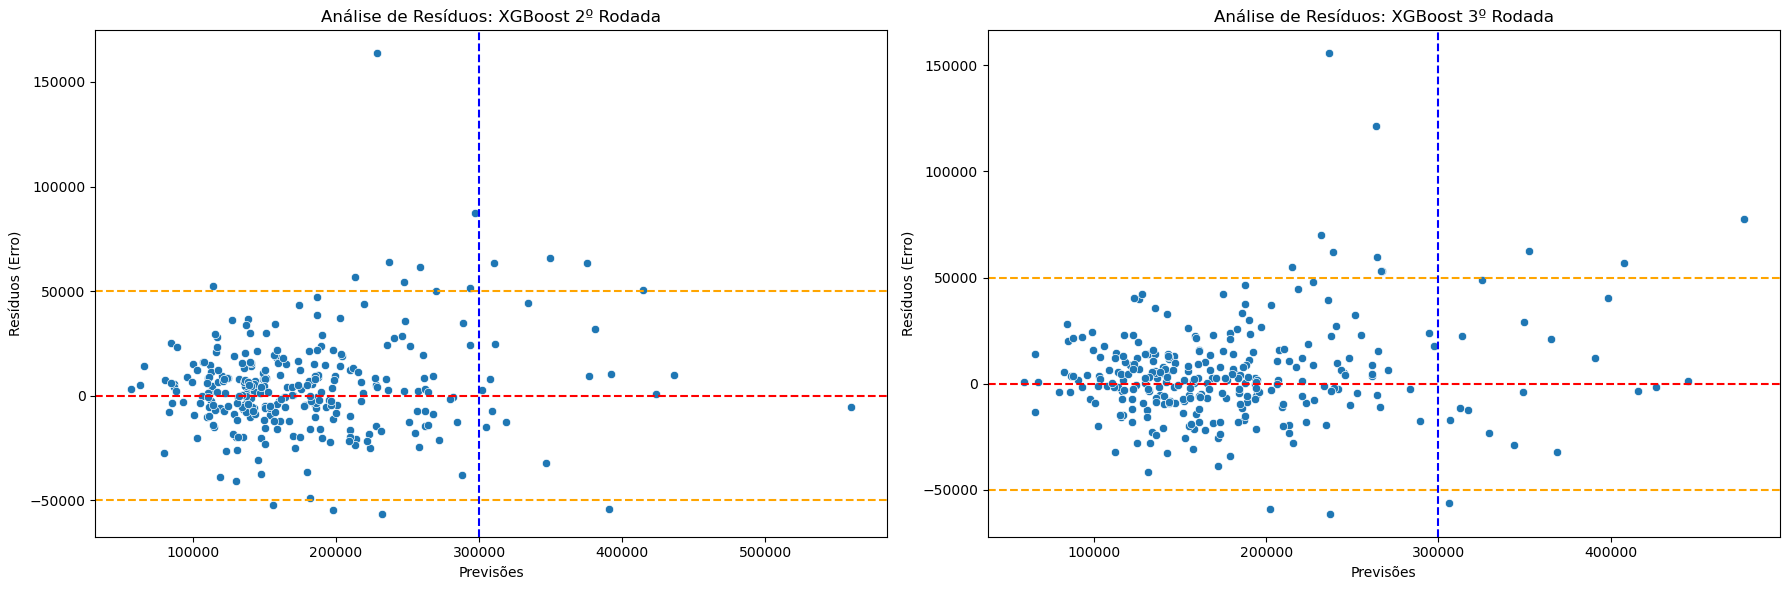

In [209]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# XGBoost 2º Rodada
residuals_xgb_2 = y_valid - xgb_preds_2
sns.scatterplot(x=xgb_preds_2, y=residuals_xgb_2, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].axhline(y=50000, color='orange', linestyle='--')
axes[0].axhline(y=-50000, color='orange', linestyle='--')
axes[0].axvline(x=300000, color='blue', linestyle='--')
axes[0].set_xlabel('Previsões')
axes[0].set_ylabel('Resíduos (Erro)')
axes[0].set_title('Análise de Resíduos: XGBoost 2º Rodada')

# XGBoost 3º Rodada
residuals_xgb_3 = y_valid - xgb_preds_3
sns.scatterplot(x=xgb_preds_3, y=residuals_xgb_3, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].axhline(y=50000, color='orange', linestyle='--')
axes[1].axhline(y=-50000, color='orange', linestyle='--')
axes[1].axvline(x=300000, color='blue', linestyle='--')
axes[1].set_xlabel('Previsões')
axes[1].set_ylabel('Resíduos (Erro)')
axes[1].set_title('Análise de Resíduos: XGBoost 3º Rodada')

plt.tight_layout()
plt.show()

In [210]:
features = ['Preco_Real', 'Previsao', 'Erro_Absoluto', 'Bairro', 'HasBsmtFin']

analise_erro = X_valid.copy()
analise_erro['Preco_Real'] = y_valid
analise_erro['Previsao'] = xgb_preds_3
analise_erro['Erro_Absoluto'] = abs(y_valid - xgb_preds_3)
analise_erro['Bairro'] = dados_treino.Neighborhood
analise_erro = analise_erro[features]

print("\nMaiores 8 erros:")
maiores_erros = analise_erro.sort_values(by='Erro_Absoluto', ascending=False)
print(maiores_erros.head(15))


Maiores 8 erros:
      Preco_Real       Previsao  Erro_Absoluto   Bairro  HasBsmtFin
688       392000  236443.968750  155556.031250  StoneBr           1
53        385000  263777.812500  121222.187500  Veenker           1
440       555000  477482.812500   77517.187500  NridgHt           1
706       302000  231805.265625   70194.734375  ClearCr           1
278       415298  352780.906250   62517.093750  NridgHt           0
322       301000  238921.468750   62078.531250  SawyerW           1
1415      175900  237129.312500   61229.312500  Blmngtn           1
326       324000  264561.093750   59438.906250  Veenker           1
588       143000  202225.796875   59225.796875  ClearCr           1
1243      465000  407991.093750   57008.906250  NridgHt           1
4         250000  306358.468750   56358.468750  NoRidge           1
764       270000  215168.078125   54831.921875  Veenker           1
45        319900  266629.937500   53270.062500  NridgHt           1
159       320000  267092.90625

#### Notas da primeira rodada

- Após remoção de outliers, tratamento de valores nulos/ausentes e feature engineering, o modelo tem apresentado uma boa capacidade de generalização, apesar de ainda possuir alguns erros consideravelmente elevados, especificamente para casas da região Norte.  
- Fazendo uma análise visual do gráfico acima, percebe-se que a última versão do modelo reduziu a dispersão dos erros para previsões no geral, principalmente para aquelas de até USD 300k.
- Ainda buscando o alvo de aproximadamente +/- USD 50k, partiremos para uma segunda rodada de Feature engineering, buscando melhorar a previsão das casas de valores elevados (Norte).

#### Feature Engineering: Parte 2

Sabendo que os maiores erros se concentram na região norte e que uma feature regional não surtiu tanto efeito, vamos avaliar os valores das casas de acordo com os bairros:

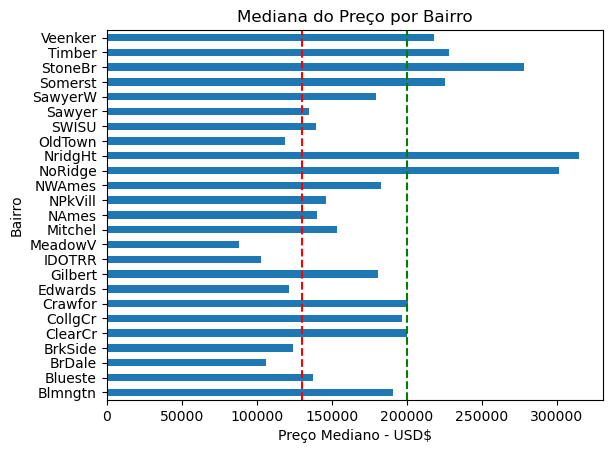

In [246]:
dados_treino.groupby('Neighborhood')['SalePrice'].median().plot(kind='barh')
plt.xlabel('Preço Mediano - USD$')
plt.ylabel('Bairro')
plt.title('Mediana do Preço por Bairro')
plt.axvline(x=130000, color='red', linestyle='--')
plt.axvline(x=200000, color='green', linestyle='--')
plt.show()

Buscando uma nova maneira para categorizar as casas, foram criadas 3 faixas com um critério apenas visual a partir do gráfico acima:
- Abaixo de USD 130k, entre USD 130k e 200k e acima de USD 200k.

Este novo critério será chamado de padrão do imóvel, pois está relacionando bairro com preço do imóvel.

In [286]:
# Criando a feature de padrão do imóvel com base na mediana do preço por bairro
preco_bairro = dados_treino.groupby('Neighborhood')['SalePrice'].median()
df_treino_2 = df_treino_round_1.copy()

# Função para categorizar os bairros
def padrao_imovel(price):
    if price <= 130000: return 0
    if price <= 200000: return 1
    return 2
padrao_bairro = preco_bairro.apply(padrao_imovel).to_dict()

Considerando que os maiores erros estão relacionados a casas com valores maiores, vamos incluir uma nova feature que possam estar relacionadas com valor agregado: Utilities.

In [287]:
def feature_engineering_2(df):
    mapping_utilities = {'ELO': 0, 'NoSeWa': 1, 'NoSewr': 2, 'AllPub': 3}
    
    df['HouseLevel'] = df['Neighborhood'].map(padrao_bairro).fillna(1).astype(int)
    df['Utilities'] = df['Utilities'].map(mapping_utilities).fillna(2).astype(int)
   
    return df

#### Treino e Validação - 2º Rodada

In [288]:
# 2º Rodada com hiperparâmetros otimizados, novas features e sem outliers

features_final = ["OverallScore",  "GrLivArea", "GarageCars","GarageArea", 
                  "TotalBsmtSF", "TotalBaths", "TotRmsAbvGrd", 
                  "GarageAge", "MasVnrArea", "Fireplaces", "BsmtFinSF1", "LotFrontage",
                  "HouseAge", "RemodAge", "TotalPorchSF", "HasMasVnr", "HasFireplace", 
                  "HasBsmtFin", "HasPorch", "Region", "HouseLevel", "Utilities"]


# 1. Definir as condições de remoção (Outliers identificados na sua análise)
remover_outliers = (
    (dados_treino['GrLivArea'] > 4000) |
    (dados_treino['BsmtFinSF1'] > 4000)|
    (dados_treino['TotalBsmtSF'] > 4000)
)

# 2. Criar um novo DataFrame apenas com os dados "limpos"
df_treino_sem_outliers = dados_treino[~remover_outliers].copy()

df_treino_round_2 = preenche_nulos_numericos(df_treino_sem_outliers)

# Feature Engineering 1
df_treino_round_2 = feature_engineering_1(df_treino_round_2)

# Feature Engineering 2A e 2B
df_treino_round_2 = feature_engineering_2(df_treino_round_2)

df_treino_round_2 = mapear_regioes_ames(df_treino_round_2)

X = pd.get_dummies(df_treino_round_2[features_final], drop_first=True)
y = np.log(df_treino_sem_outliers.SalePrice)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

#XGBoost
xgb_model_4 = XGBRegressor(n_estimators=5000, learning_rate=0.005, max_depth=3, subsample=0.7, colsample_bytree=0.3, reg_alpha = 0, reg_lambda = 3, random_state=0, n_jobs = -1)

xgb_model_4.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=100)
xgb_preds_4 = np.exp(xgb_model_4.predict(X_valid))

scores = -1 * cross_val_score(xgb_model_4, X, np.exp(y), cv=5, scoring='neg_mean_absolute_error')
print(f"MAE Médio (Cross-Validation): {scores.mean()}")
print("XGBoost Mean Absolute Error:", mean_absolute_error(np.exp(y_valid), xgb_preds_4))  


[0]	validation_0-rmse:0.38851
[100]	validation_0-rmse:0.29520
[200]	validation_0-rmse:0.23323
[300]	validation_0-rmse:0.19181
[400]	validation_0-rmse:0.16555
[500]	validation_0-rmse:0.14893
[600]	validation_0-rmse:0.13879
[700]	validation_0-rmse:0.13238
[800]	validation_0-rmse:0.12797
[900]	validation_0-rmse:0.12481
[1000]	validation_0-rmse:0.12277
[1100]	validation_0-rmse:0.12124
[1200]	validation_0-rmse:0.12026
[1300]	validation_0-rmse:0.11961
[1400]	validation_0-rmse:0.11903
[1500]	validation_0-rmse:0.11847
[1600]	validation_0-rmse:0.11808
[1700]	validation_0-rmse:0.11787
[1800]	validation_0-rmse:0.11762
[1900]	validation_0-rmse:0.11737
[2000]	validation_0-rmse:0.11720
[2100]	validation_0-rmse:0.11705
[2200]	validation_0-rmse:0.11686
[2300]	validation_0-rmse:0.11674
[2400]	validation_0-rmse:0.11662
[2500]	validation_0-rmse:0.11662
[2600]	validation_0-rmse:0.11660
[2700]	validation_0-rmse:0.11659
[2800]	validation_0-rmse:0.11659
[2900]	validation_0-rmse:0.11655
[3000]	validation_0-rm

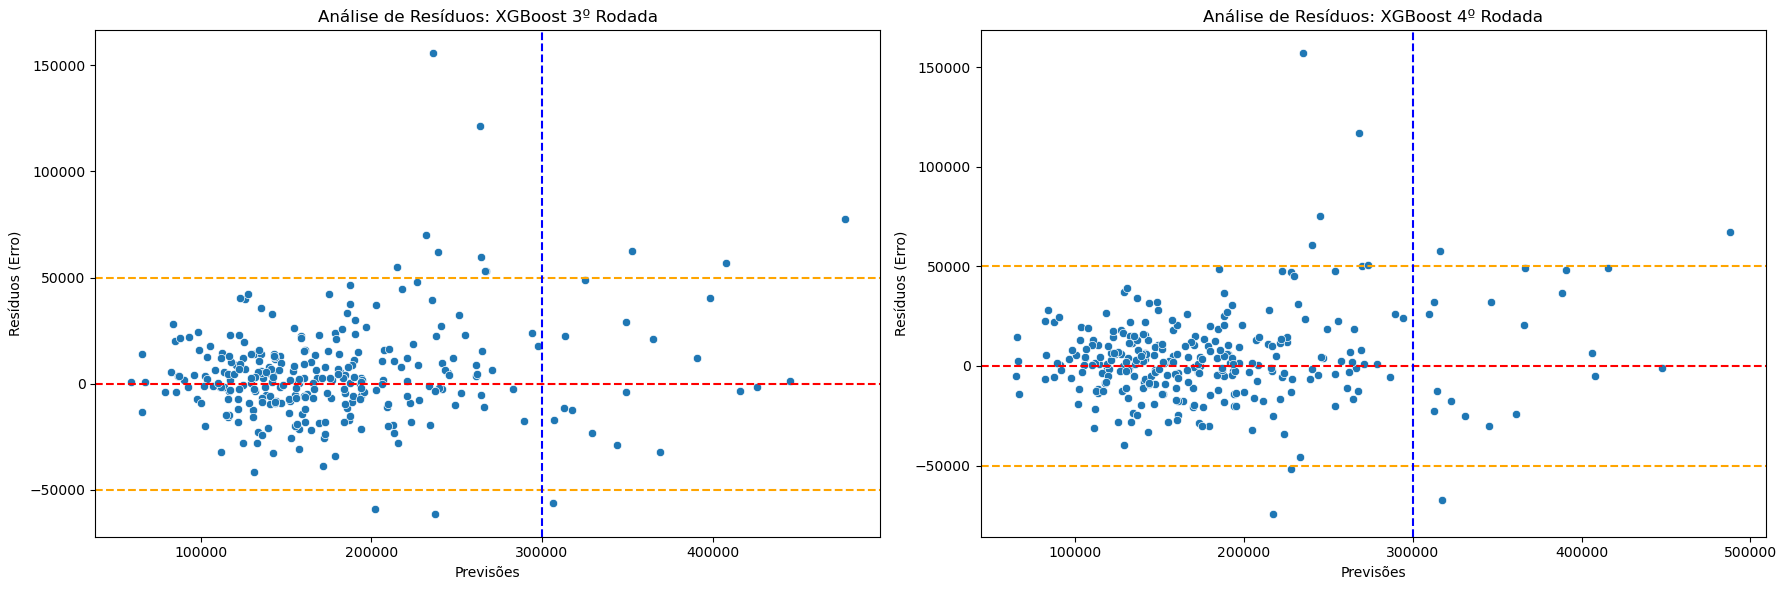

In [289]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# XGBoost 3º Rodada
sns.scatterplot(x=xgb_preds_3, y=residuals_xgb_3, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].axhline(y=50000, color='orange', linestyle='--')
axes[0].axhline(y=-50000, color='orange', linestyle='--')
axes[0].axvline(x=300000, color='blue', linestyle='--')
axes[0].set_xlabel('Previsões')
axes[0].set_ylabel('Resíduos (Erro)')
axes[0].set_title('Análise de Resíduos: XGBoost 3º Rodada')

# XGBoost 4º Rodada
residuals_xgb_4 = np.exp(y_valid) - xgb_preds_4
sns.scatterplot(x=xgb_preds_4, y=residuals_xgb_4, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].axhline(y=50000, color='orange', linestyle='--')
axes[1].axhline(y=-50000, color='orange', linestyle='--')
axes[1].axvline(x=300000, color='blue', linestyle='--')
axes[1].set_xlabel('Previsões')
axes[1].set_ylabel('Resíduos (Erro)')
axes[1].set_title('Análise de Resíduos: XGBoost 4º Rodada')

plt.tight_layout()
plt.show()

#### Notas da segunda rodada

- O XGBoost performou melhor do que a primeira rodada, reduzindo o MAE médio para 15390.29 (queda de 4%).
- A diferença entre o MAE médio (Cross-Validation) e MAE caiu para 0.96%, o que indica que a validação é estatisticamente representativa, além do modelo possuir boa capacidade de generalização.
- Apesar das melhorias obtidas no geral, o modelo possui limitações com casas da região Norte, provavelmente por ter assimilado os bairros mais luxuosos com maiores áreas, número de banheiros e outros fatores que não foram explorados a fundo nessa investigação.

De forma geral o modelo atingiu um erro ligeiramente acima da meta de USD 50k para a maioria dos imóveis, portanto partiremos para o treino com 100% dos dados de treino e implementação.  

#### Treino 100% e Análise preditiva

In [ ]:
# Treino e Teste Final
# Limpeza dos dados de treino e teste

features_final = ["OverallScore",  "GrLivArea", "GarageCars","GarageArea", 
                  "TotalBsmtSF", "TotalBaths", "TotRmsAbvGrd", 
                  "GarageAge", "MasVnrArea", "Fireplaces", "BsmtFinSF1", "LotFrontage",
                  "HouseAge", "RemodAge", "TotalPorchSF", "HasMasVnr", "HasFireplace", 
                  "HasBsmtFin", "HasPorch", "Region", "HouseLevel", "Utilities"]


# 1. Definir as condições de remoção (Outliers identificados na sua análise)
remover_outliers = (
    (dados_treino['GrLivArea'] > 4000) |
    (dados_treino['BsmtFinSF1'] > 4000)|
    (dados_treino['TotalBsmtSF'] > 4000)
)

df_treino_sem_outliers = dados_treino[~remover_outliers].copy()

df_treino_final = preenche_nulos_numericos(df_treino_sem_outliers)
df_teste = preenche_nulos_numericos(dados_teste)

# Feature Engineering 1
df_treino_final = feature_engineering_1(df_treino_final)
df_teste = feature_engineering_1(df_teste)

# Feature Engineering 2
df_treino_final = feature_engineering_2(df_treino_final)
df_teste = feature_engineering_2(df_teste)

# Mapeamento de regiões
df_treino_final = mapear_regioes_ames(df_treino_final)
df_teste = mapear_regioes_ames(df_teste)

# Treino final
X_final = pd.get_dummies(df_treino_final[features_final], drop_first=True)
y_final = np.log(df_treino_final.SalePrice)

xgb_modelo_final = XGBRegressor(n_estimators=5000, learning_rate=0.005, max_depth=3, subsample=0.7, colsample_bytree=0.4, reg_alpha = 0, reg_lambda = 3, random_state=0, n_jobs = -1)
xgb_modelo_final.fit(X_final, y_final)

# Teste e geração dos csv com outputs
X_test_final = pd.get_dummies(df_teste[features_final], drop_first=True)
X_test_final = X_test_final.reindex(columns=X_final.columns, fill_value=0)

predicao_final = np.exp(xgb_modelo_final.predict(X_test_final))
output = pd.DataFrame({'Id': dados_teste.Id, 'SalePrice': predicao_final})
output.to_csv('predicao_final_Git.csv', index=False)
print("Primeiras 5 linhas da predição final:")
print(pd.DataFrame(predicao_final, columns =['SalePrice $USD']).head(5))
print("\nPredição concluída!")


Primeiras 5 linhas da predição final:
   SalePrice $USD
0   127678.515625
1   153381.609375
2   183951.234375
3   195595.593750
4   186256.859375

Predição concluída!


#### NOTAS FINAIS: 

- Foram testadas outras features na tentativa de reduzir os erros das casas da região norte, porém sem sucesso. Algumas delas foram: Foundation, Electrical, SaleCondition, SaleType, GarageScore (combinação de vários aspectos da garagem), KitchenScore (nota geral da cozinha), CentralAir, HeatingScore (nota geral do aquecimento).
- Como plano de melhorias para o modelo sugiro a criação de novas features que traduzam melhor as casas de padrão mais alto, porém com características fora do convencional
- Devido aos erros acima de USD 50k, sugere-se o uso deste modelos para casas de baixo e médio padrão na região de Ames, Iowa.


### Gráfico utilizado no README.md

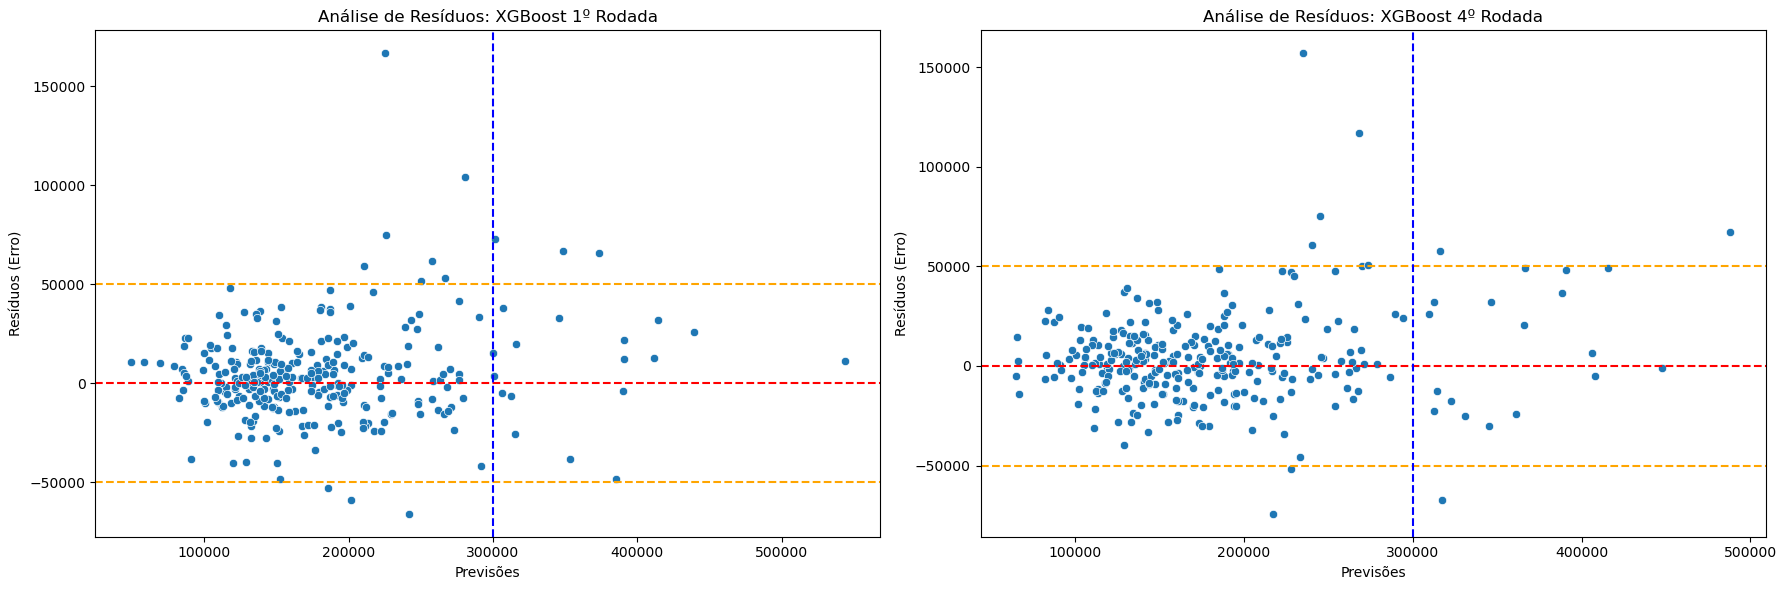

In [291]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# XGBoost 1º Rodada
sns.scatterplot(x=xgb_preds_1, y=residuals_xgb_1, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].axhline(y=50000, color='orange', linestyle='--')
axes[0].axhline(y=-50000, color='orange', linestyle='--')
axes[0].axvline(x=300000, color='blue', linestyle='--')
axes[0].set_xlabel('Previsões')
axes[0].set_ylabel('Resíduos (Erro)')
axes[0].set_title('Análise de Resíduos: XGBoost 1º Rodada')

# XGBoost 4º Rodada
sns.scatterplot(x=xgb_preds_4, y=residuals_xgb_4, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].axhline(y=50000, color='orange', linestyle='--')
axes[1].axhline(y=-50000, color='orange', linestyle='--')
axes[1].axvline(x=300000, color='blue', linestyle='--')
axes[1].set_xlabel('Previsões')
axes[1].set_ylabel('Resíduos (Erro)')
axes[1].set_title('Análise de Resíduos: XGBoost 4º Rodada')

plt.tight_layout()
plt.show()